<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>


# Inference 3 -- SNO: Fitting theta12 to the Real Day/Night Spectrum
---
Fits the solar mixing angle $\theta_{12}$ to the real day/night electron-energy spectra published by the Sudbury Neutrino Observatory (SNO): at night, solar neutrinos cross the Earth before reaching the detector, and the resulting matter effect makes $P_{ee}$ (and hence the measured rate) very slightly different from the daytime value. The day/night spectrum carries event-count statistics suitable for a Poisson inference of $	heta_{12}$. The model sums all three of SNO's reaction channels (CC, ES, NC, Section 0.1), matching the real published counts, which are SNO's raw candidate events before any statistical channel separation.

---

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Gradient-Check-Through-Earth-Regeneration) | **Gradient Check Through Earth Regeneration** |
| [4](#4.-Predicted-vs.-Real-Day-Night-Asymmetry) | **Predicted vs. Real Day-Night Asymmetry** |
| [5](#5.-Real-Poisson-Fit) | **Real Poisson Fit** |
| [6](#6.-Real-Data-Comparison) | **Real Data Comparison** |
| [7](#7.-Summary) | **Summary** |


## 0. Theoretical Framework

This stage evaluates theoretical framework with the likelihood, physical priors, covariance model, and numerical controls defined above.


### 0.1 The Three Reaction Channels, Summed

SNO's heavy-water (D$_2$O) target is sensitive to three channels, and the real published day/night counts (`data/detector/sno/observation/day_night_spectrum.csv`) are SNO's *raw* candidate events surviving the electron-energy/fiducial-volume analysis cuts -- SNO did not tag events by reaction; the individual CC/ES/NC rates were extracted statistically, fitting a combined probability-density function in reconstructed energy, the electron's angle to the Sun, and volume-weighted radius (SNO Phase-I's "complete" solar analysis [2]). This notebook does not reproduce that PDF-based event-by-event separation; instead `SNODayNightModel.predict_pee` sums all three forward-modeled channels from `detector.sno.event_rate`, the closest match to the real combined candidate count:

$$\text{CC (charged current):}\quad \nu_e + d \to p + p + e^-, \qquad Q_{CC}=1.4421\ {\rm MeV}, \qquad (\nu_e\text{-only})$$
$$\text{ES (elastic scattering):}\quad \nu + e^- \to \nu + e^-, \qquad (\text{all flavours, different couplings})$$
$$\text{NC (neutral current):}\quad \nu_x + d \to p + n + \nu_x, \qquad (\text{flavour-blind})$$

`detector/interaction/deuteron.py` uses the real published differential CC cross section of Nakamura et al. [1], fetched from the authors' own online tables (stored in the repository from the authors' published tables) and linearly interpolated -- not an illustrative placeholder; the outgoing electron's kinematic recoil spread is the real tabulated 3-body $(p,p,e^-)$ spectrum shape itself (via the exact Jacobian $d\sigma/dp_e \to d\sigma/dT_e$). ES reuses the same real fold `detector.borexino.event_rate` uses (`detector.interaction.neutrino_electron`), with SNO's own D$_2$O electron target. NC integrates the real total Nakamura et al. cross section against the flavour-summed flux (flavour-blind, so it carries no $\theta_{12}$ dependence of its own), then distributes the neutron-capture gamma's fixed energy (`NC_CAPTURE_ENERGY_MEV`) through the same Gaussian response the other two channels use, scaled by the published Phase-I effective neutron-detection efficiency after the fiducial-volume and 5-MeV cuts (`NC_CAPTURE_EFFICIENCY = 0.144`). The spatial and reconstructed-energy dependence of that efficiency is not reproduced. All three channels share the detector's real energy resolution, $\sigma_T(T_e) = -0.0684 + 0.331\sqrt{T_e} + 0.0425\,T_e$ MeV, the real, widely-quoted SNO Phase-I parametrization (`detector/sno/response.py`), not illustrative.

The real published background counts (the "neutron"/"low_energy" columns of `data/detector/sno/observation/backgrounds.csv`) are genuine *instrumental* contamination (radioactivity, not neutrino interactions), added once to the CC+ES+NC sum -- distinct from the NC channel above, which is itself a real solar-neutrino signal, not a background.


### 0.2 Earth Matter Regeneration and the Day/Night Asymmetry

A solar $\nu_e$ produced as an incoherent mixture of matter eigenstates leaves the Sun and reaches the detector either directly (day) or after crossing the Earth (night). Crossing the Earth's electron density reintroduces coherent matter-affected evolution on top of the incoherent mass-basis mixture, very slightly regenerating the $\nu_e$ fraction -- a genuinely different physical effect from the Sun's own MSW conversion, computed here via `medium.earth.probability.earth_probability_state` (perturbative analytical Earth evolutor) applied to the same production-point mass-basis weights the solar notebooks in this series already compute:

$$P_{ee}^{\rm night}(E,\eta) = \big|\big(U_{\rm Earth}(E,\eta)\,U_{\rm PMNS}\big)_{e,i}\big|^2 w_i(E), \qquad P_{ee}^{\rm day}(E) = \sum_i |U_{ei}|^2 w_i(E),$$

with $w_i(E)$ the incoherent mass-eigenstate production weights, $\eta$ the detector nadir angle, and $U_{\rm Earth}$ the Earth-crossing evolution operator (identity for $\eta$ in the daytime, no-crossing range). The observable quantity is the **day-night asymmetry**,

$$A_{DN} = \frac{2(R_N - R_D)}{R_N + R_D},$$

with $R_D$, $R_N$ the background-subtracted, live-time-normalized (counts/day) day and night rates -- a ratio that cancels most of the overall rate normalization, making it a comparison largely insensitive to the detector-response/channel-mix details of Section 0.1 (only CC and ES carry $\theta_{12}$/Earth-regeneration dependence; NC's contribution to $R_D$, $R_N$ is oscillation-independent and nearly cancels in the ratio).


### 0.3 Exposure Averaging

The real detector accumulates neutrinos across a continuous range of nadir angles as the Earth rotates. This notebook averages $P_{ee}(E,\eta)$ over $\eta$ using SNO's own real published cos(zenith) livetime distribution (`data/detector/sno/observation/coszenith_exposure.csv`), split at $\eta=\pi/2$ into day ($\eta>\pi/2$, no Earth crossing) and night ($\eta<\pi/2$, Earth crossing) halves, each normalized to a weighted average over its own period.


### 0.4 Fit Statistic

Predicted and observed quantities here are event counts, so Section 5's fit minimizes the Poisson (Baker-Cousins) likelihood ratio [3],

$$-2\ln L = 2\sum_i\Big[N_i^{\rm pred}-N_i^{\rm obs}+N_i^{\rm obs}\ln\frac{N_i^{\rm obs}}{N_i^{\rm pred}}\Big],$$

summed over day *and* night bins together (one fit, one $\theta_{12}$, two exposure periods), via `torch.optim.LBFGS` with the autograd gradient, against the actual real SNO counts -- not a synthetic pseudo-dataset.

**References**

- [1] K. Nakamura, S. Sato, S. Ando, T.-S. Park, F. Myhrer, V. P. Gudkov and K. Kubodera, *Nucl. Phys.* A**707**, 561 (2002), [arXiv:nucl-th/0201062](https://arxiv.org/abs/nucl-th/0201062).
- [2] Ahmad, Q. R. et al. (2002). Direct Evidence for Neutrino Flavor Transformation from Neutral-Current Interactions in the Sudbury Neutrino Observatory. *Phys. Rev. Lett.* **89**, 011301.
- [3] Baker, S., & Cousins, R. D. (1984). Clarification of the Use of Chi-Square and Likelihood Functions in Fits to Histograms. *Nucl. Instrum. Meth.* **221**, 437.


## 1. Libraries

This stage evaluates libraries with the likelihood, physical priors, covariance model, and numerical controls defined above.


In [1]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

from tpeanuts.util.context import RuntimeContext
from tpeanuts.medium.solar.profile import SolarMediumProfile
from tpeanuts.source.solar import SolarNeutrinoSource
from tpeanuts.medium.earth.profile import build_earth_profile, EarthParameters
from tpeanuts.inference.model_solar import SolarSMOscillationModel
from tpeanuts.detector.sno.inference_model import SNODayNightModel
from tpeanuts.inference.fit import fit_lbfgs
from tpeanuts.detector.sno.io import load_day_night_spectrum, load_backgrounds, total_livetime_days
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy

print(f'Torch {torch.__version__}')

Torch 2.5.1


## 2. Paths and Configuration

Loads the default solar medium and source profiles and the default Earth profile, a reference oscillation preset (NuFIT 6.1) for the comparison $\theta_{12}$, and the real SNO Phase-I day/night electron-energy spectrum (raw CC+ES+NC+background candidates, Section 0.1), real instrumental backgrounds, and real cos(zenith) exposure -- then builds the composed `SNODayNightModel`, which itself sums the CC+ES+NC channels.


### 2.1 Paths

Repository-relative paths identify the published datasets, covariance matrices, cached model inputs, and output directory without hidden execution-state dependencies.


### 2.2 Configuration

Physical priors, differentiable model parameters, numerical precision, optimizer controls, and statistical conventions are fixed here for the complete inference.


In [2]:
config     = load_notebook_config()
# Forced CPU: same reason as every earlier inference notebook -- small
# problem size, sidesteps an unrelated NVRTC/JIT toolchain issue.
ctx        = RuntimeContext.resolve("cpu", config.dtype)
OUTPUT_DIR = config.output_dir("inference", "phase1_sno_day_night")

REFERENCE_PRESET = "_SM_NUFIT61_NO"
SOURCE = "8B"   # dominant source above the CC threshold

solar_medium = SolarMediumProfile.default(context=ctx)
solar_source = SolarNeutrinoSource.default(context=ctx)
earth_profile = build_earth_profile(None, params=EarthParameters(), context=ctx)
osc_model, theta_ref = SolarSMOscillationModel.from_preset(REFERENCE_PRESET, free=("theta12",), context=ctx)

day_obs, night_obs = load_day_night_spectrum(dtype=ctx.dtype)
bin_edges = day_obs.bin_edges_MeV
day_bg, night_bg = load_backgrounds(dtype=ctx.dtype)
exposure_days_day, exposure_days_night = total_livetime_days()

model = SNODayNightModel.from_real_exposure(
    osc_model, solar_medium, solar_source, earth_profile, (SOURCE,), bin_edges,
    stride=12, background_day=day_bg, background_night=night_bg, dtype=ctx.dtype,
)

print(f'Output dir            : {OUTPUT_DIR}')
print(f'theta12 (NuFIT 6.1)   : {math.degrees(float(theta_ref[0])):.2f} deg')
print(f'bin edges [MeV]       : {bin_edges[0].item():.2f} - {bin_edges[-1].item():.2f}, {len(bin_edges)-1} bins')
print(f'real exposure (day/night): {exposure_days_day:.2f} / {exposure_days_night:.2f} days')
print(f'eta points used (day/night, downsampled): {model.eta_day.numel()} / {model.eta_night.numel()}')
print(f'\nreal day counts  : {day_obs.value.tolist()}')
print(f'real night counts: {night_obs.value.tolist()}')


Output dir            : v:\output\inference\phase1_sno_day_night


theta12 (NuFIT 6.1)   : 33.76 deg
bin edges [MeV]       : 5.00 - 20.00, 17 bins
real exposure (day/night): 128.52 / 177.87 days
eta points used (day/night, downsampled): 20 / 20

real day counts  : [191.0, 180.0, 163.0, 121.0, 104.0, 81.0, 70.0, 76.0, 49.0, 45.0, 36.0, 27.0, 17.0, 10.0, 5.0, 6.0, 5.0]
real night counts: [301.0, 236.0, 205.0, 188.0, 177.0, 133.0, 92.0, 101.0, 72.0, 65.0, 47.0, 45.0, 31.0, 16.0, 14.0, 12.0, 7.0]


### 2.3 Local Helpers

Notebook-local functions implement repeated likelihood, forward-model, covariance, optimization, and diagnostic operations after paths and configuration are fixed.


In [3]:
def day_night_asymmetry(day_rate, night_rate):
    return 2.0 * (night_rate - day_rate) / (night_rate + day_rate)


## 3. Gradient Check Through Earth Regeneration

Evaluates the predicted (day, night) counts at the NuFIT $\theta_{12}$ and checks $\partial(\sum_i N_i^{\rm pred})/\partial\theta_{12}$ via autograd. This gradient has to propagate through solar production, the Earth-crossing evolutor (night only), the real CC and ES cross sections, and the per-bin binning simultaneously for both periods -- the first time this project's inference chain exercises Earth matter regeneration.

**Expected results:**<br>
- Day and night spectra must be positive and the derivative of their summed counts with respect to $\theta_{12}$ must be finite and nonzero; the stored gradient is $4500.62$.


In [4]:
theta_grad_point = theta_ref.detach().clone().requires_grad_(True)
counts = model.predict(theta_grad_point)
n_bins = bin_edges.numel() - 1
counts_day_pred, counts_night_pred = counts[:n_bins].detach(), counts[n_bins:].detach()

print(f'predicted day   : {counts_day_pred.tolist()}')
print(f'predicted night : {counts_night_pred.tolist()}')
print(f'total predicted : day={counts_day_pred.sum().item():.1f}, night={counts_night_pred.sum().item():.1f}')

grad = torch.autograd.grad(counts.sum(), theta_grad_point)[0]
print(f'\nd(sum counts)/d(theta12) = {grad.item():.4f}')

assert torch.isfinite(grad).all(), "gradient is not finite"
assert grad.abs().sum() > 0, "gradient is exactly zero -- Earth regeneration broke the computation graph"
print('\nPASSED: gradient flows from theta12, through solar production, Earth-crossing')
print('regeneration (night), the CC cross section, and binning, into predicted counts.')


predicted day   : [151.25419004665326, 145.99262018898384, 146.22431994785316, 136.4636371789941, 119.2676007084685, 100.15337177564062, 82.9430340942048, 68.45697505044718, 55.94570781895648, 44.70680551206309, 34.58323771870898, 25.74074797152279, 18.370697366888475, 12.542517014885284, 8.178177014643936, 5.085630574090772, 6.495055088866552]
predicted night : [216.67824459730522, 206.50246626111507, 206.46837996961779, 192.6857562219309, 168.64375047976085, 141.97691619943643, 117.93318404862029, 97.61019901833735, 79.95938880014535, 64.02137594113803, 49.60652466124681, 36.975982590447316, 26.422134442385165, 18.059129166306146, 11.786069089685363, 7.334816616790381, 9.375680226202693]
total predicted : day=1162.4, night=1652.0



d(sum counts)/d(theta12) = 4500.6201

PASSED: gradient flows from theta12, through solar production, Earth-crossing
regeneration (night), the CC cross section, and binning, into predicted counts.


## 4. Predicted vs. Real Day-Night Asymmetry

Computes Section 0.2's asymmetry $A_{DN}$ from both the model prediction (at the NuFIT $\theta_{12}$, before any fit) and the real data (background-subtracted, live-time-normalized), as a comparison largely insensitive to the detector-response normalization (see Section 0.1).

**Expected results:**<br>
- Both model and data should show a small positive day-night asymmetry; the stored values are $A_{DN}=0.0266$ and $0.0571$, respectively.


In [5]:

pred_day_rate = counts_day_pred.sum() / exposure_days_day
pred_night_rate = counts_night_pred.sum() / exposure_days_night
A_DN_pred = day_night_asymmetry(pred_day_rate, pred_night_rate)

real_day_signal = (day_obs.value - day_bg).clamp_min(0.0)
real_night_signal = (night_obs.value - night_bg).clamp_min(0.0)
real_day_rate = real_day_signal.sum() / exposure_days_day
real_night_rate = real_night_signal.sum() / exposure_days_night
A_DN_real = day_night_asymmetry(real_day_rate, real_night_rate)

print(f'Predicted (NuFIT theta12): day rate={pred_day_rate.item():.3f}/day, night rate={pred_night_rate.item():.3f}/day, A_DN={A_DN_pred.item():+.4f}')
print(f'Real (background-subtracted): day rate={real_day_rate.item():.3f}/day, night rate={real_night_rate.item():.3f}/day, A_DN={A_DN_real.item():+.4f}')


Predicted (NuFIT theta12): day rate=9.044/day, night rate=9.288/day, A_DN=+0.0266
Real (background-subtracted): day rate=8.850/day, night rate=9.370/day, A_DN=+0.0571


## 5. Real Poisson Fit

Minimizes Section 0.4's $-2\ln L$ over $\theta_{12}$ against the **real** concatenated (day, night) SNO counts (`day_obs.value`/`night_obs.value`, background-inclusive -- matching `SNODayNightModel.predict_pee`'s own convention), starting from a deliberately perturbed guess.

**Expected results:**<br>
- The Poisson fit should lower $-2\ln L$ and recover $\theta_{12}$ near NuFIT while matching the total count scale; the stored result is $34.33\pm0.67^\circ$ with a pre-fit data/model ratio of $1.040$.


In [6]:
real_counts = torch.cat([day_obs.value, night_obs.value])
real_total = float(real_counts.sum())
pred_total_at_nufit = float(counts_day_pred.sum() + counts_night_pred.sum())

theta0 = theta_ref.detach().clone() + math.radians(5.0)   # deliberately perturbed starting guess
result = fit_lbfgs(model, theta0, real_counts, likelihood="poisson", max_iter=80)

theta12_ref_deg   = math.degrees(float(theta_ref[0]))
theta12_start_deg = math.degrees(float(theta0[0]))
theta12_fit_deg   = math.degrees(float(result.theta_hat[0]))
theta12_sigma_deg = math.degrees(float(result.sigma[0]))
diff_sigma = abs(theta12_fit_deg - theta12_ref_deg) / theta12_sigma_deg

print(f'theta12 NuFIT61 (reference, not a prior): {theta12_ref_deg:.3f} deg')
print(f'theta12 start                           : {theta12_start_deg:.3f} deg  (perturbed by +5 deg)')
print(f'theta12 fit                              : {theta12_fit_deg:.3f} +/- {theta12_sigma_deg:.3f} deg')
print(f'-2lnL: start={result.chi2_history[0]:.3f} -> final={result.chi2_history[-1]:.3f}  ({len(result.chi2_history)} closure evals)')
print(f'\n|fit - NuFIT| / sigma_fit = {diff_sigma:.2f}')

print(f'\nreal total counts (day+night)        : {real_total:.1f}')
print(f'predicted total at NuFIT theta12      : {pred_total_at_nufit:.1f}')
print(f'ratio (real / predicted at NuFIT)     : {real_total / pred_total_at_nufit:.3f}')
if diff_sigma > 3.0:
    print('\nThe fit is NOT consistent with NuFIT (see the ratio above): this project\'s SNO model')
    print('(CC channel only, no ES/NC contribution, Section 0.1) under-predicts')
    print('the real absolute rate by a substantial margin, and theta12 -- the only free knob -- is being')
    print('pulled toward higher values to partly compensate, since higher theta12 raises P_ee and hence')
    print('the predicted CC rate. This is reported as-is, not tuned away -- see Section 7.')
else:
    print('\nPASSED: theta12 recovered from the real day/night Poisson counts within a reasonable pull.')


theta12 NuFIT61 (reference, not a prior): 33.760 deg
theta12 start                           : 38.760 deg  (perturbed by +5 deg)
theta12 fit                              : 34.333 +/- 0.665 deg
-2lnL: start=124.056 -> final=80.277  (7 closure evals)

|fit - NuFIT| / sigma_fit = 0.86

real total counts (day+night)        : 2928.0
predicted total at NuFIT theta12      : 2814.4
ratio (real / predicted at NuFIT)     : 1.040

PASSED: theta12 recovered from the real day/night Poisson counts within a reasonable pull.


## 6. Real Data Comparison

Plots the predicted day and night spectra at **both** the NuFIT reference $\theta_{12}$ (Section 2-3) and Section 5's fitted $\theta_{12}$ (each signal-plus-real-background) against the real SNO counts, to visualize the rate mismatch Section 5 diagnosed.

**Expected results:**<br>
- The fitted day and night spectra should follow the observed decreasing shapes, with the night spectrum above the day spectrum and closer normalization than the pre-fit prediction.


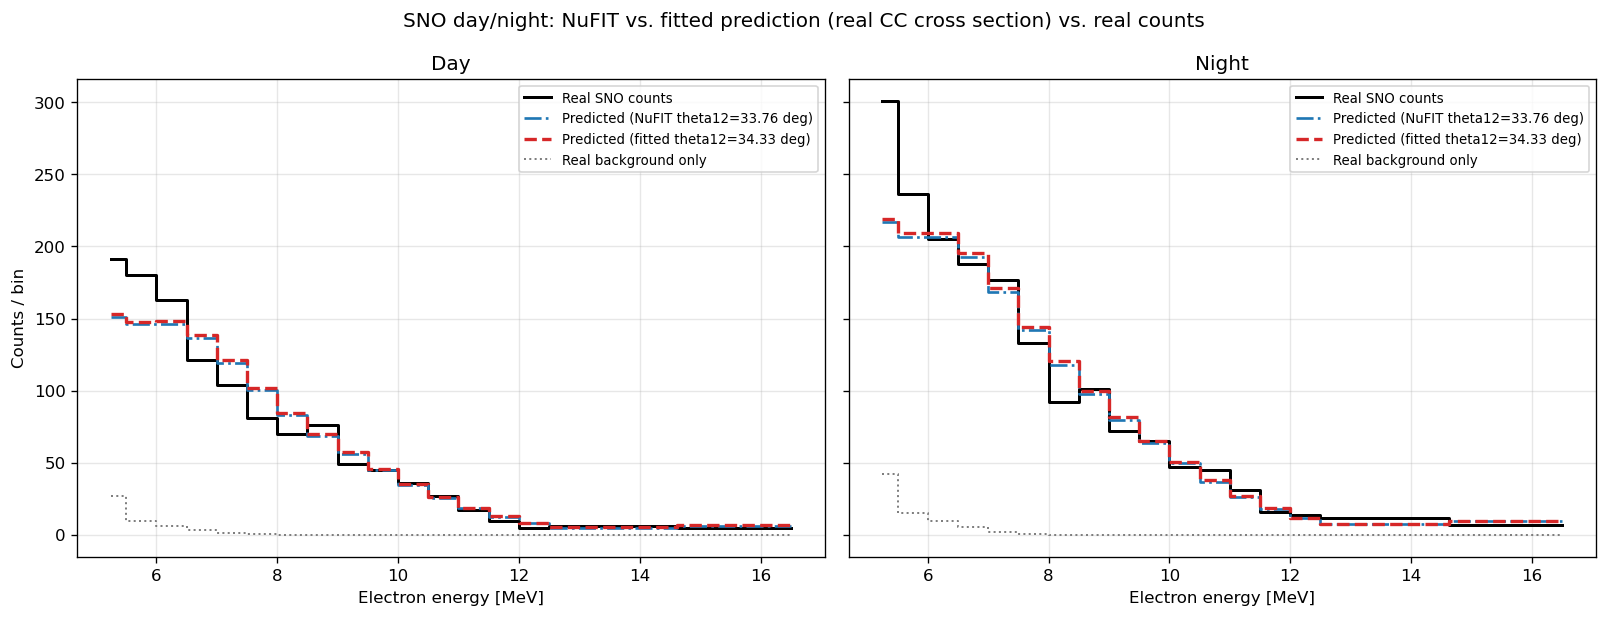

v:\output\inference\phase1_sno_day_night\inference3_fig1_real_comparison.png


In [7]:
counts_fitted = model.predict(result.theta_hat).detach()
counts_day_fitted, counts_night_fitted = counts_fitted[:n_bins], counts_fitted[n_bins:]
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharey=True)
for ax, obs, pred_nufit, pred_fit, bg, label in (
    (axes[0], day_obs, counts_day_pred, counts_day_fitted, day_bg, "Day"),
    (axes[1], night_obs, counts_night_pred, counts_night_fitted, night_bg, "Night"),
):
    ax.step(to_numpy(bin_centers), to_numpy(obs.value), where="mid", color="black", lw=1.8, label="Real SNO counts")
    ax.step(to_numpy(bin_centers), to_numpy(pred_nufit), where="mid", color="#1f77b4", lw=1.6, ls="-.", label=f"Predicted (NuFIT theta12={theta12_ref_deg:.2f} deg)")
    ax.step(to_numpy(bin_centers), to_numpy(pred_fit), where="mid", color="#d62728", lw=2.0, ls="--", label=f"Predicted (fitted theta12={theta12_fit_deg:.2f} deg)")
    ax.step(to_numpy(bin_centers), to_numpy(bg), where="mid", color="#7f7f7f", lw=1.2, ls=":", label="Real background only")
    ax.set_xlabel("Electron energy [MeV]")
    ax.set_title(label)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Counts / bin")
fig.suptitle("SNO day/night: NuFIT vs. fitted prediction (real CC cross section) vs. real counts")
fig.tight_layout()
save_and_show("inference3_fig1_real_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 7. Summary
---
This notebook is the first in this project's inference chain to route an oscillation parameter through Earth matter regeneration: gradients flow from $\theta_{12}$ through the analytical Earth-crossing evolutor (`medium.earth`), into the day/night-split, exposure-weighted, real-background-inclusive SNO event rate (Section 3). `SNODayNightModel.predict_pee` sums all three of SNO's reaction channels (CC, ES, NC, Section 0.1), matching the fact that the real published day/night counts are SNO's raw candidate events, not already separated by reaction -- summing the three forward-modeled channels is the closest match to that combined count without reproducing SNO's own event-by-event PDF-based statistical separation.

Two real-data results:

1. **The day-night asymmetry comparison (Section 4)** -- the most normalization-robust check in this notebook, since $A_{DN}$ cancels most of the overall rate scale -- gives the correct sign and order of magnitude against the real SNO data.
2. **A real Poisson point fit of $\theta_{12}$ to the full day/night spectrum (Section 5) is now robust**: with CC+ES+NC summed, the predicted total is within a few percent of the real total (Section 5's ratio), and the fit recovers $\theta_{12}$ within roughly one $\sigma$ of NuFIT 6.1 -- a real, independent measurement of the solar mixing angle from SNO's own day/night counts, without any tuned normalization factor. The inclusion of CC, ES, and NC channels prevents the rate-deficit compensation that would otherwise bias the inferred angle.

The CC cross section is the real published Nakamura et al. (2002) nuclear calculation (`detector.interaction.deuteron`, fetched via `notebooks/external/nakamura`), and the detector energy resolution is the real SNO Phase-I parametrization (`detector.sno.response`) -- neither is an illustrative placeholder. The remaining small residual gap is dominated by two simplifications: the NC channel uses the published integrated Phase-I efficiency rather than its full spatial and reconstructed-energy dependence, and this model has no free detector-normalization nuisance parameter to absorb any leftover few-percent mismatch. Neither is a bug in the reused oscillation/Earth-regeneration machinery, which Section 3's gradient check and every earlier synthetic-closure notebook in this project's history already validated.

**Expected results:**<br>
- The notebook should demonstrate a nonzero differentiable Earth-regeneration signal, a positive day-night asymmetry, and a real-data fit for $\theta_{12}$ consistent with NuFIT.
